# Neural Networks for Handwritten Digit Recognition, Multiclass

This is an example of a neural network that tries to recognize hand written digits from 0 to 9.

In [16]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import linear, relu, sigmoid
%matplotlib widget
import matplotlib.pyplot as plt
plt.style.use('./lib/deeplearning.mplstyle')

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

from lib.public_tests import * 

from lib.autils import *
from lib.lab_utils_softmax import plt_softmax
np.set_printoptions(precision=2)

## 2 - ReLU Activation

formula: $a=max(0,z)$

Reminder:
- **Sigmoid activaiton**: Best for on/off or binary situations.
- **ReLU**: Provides a continuous linera relationship. It als has an "off" rante where the output is zero. This is why ReLU is not considered to be "linear".

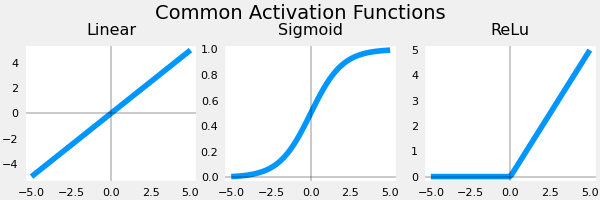

In [17]:
plt_act_trio()

## 3 - Softmad Function

A multiclass neural network produces N outputs. One of the outputs is selected as the predicted answer.
- The output layer generates a vector *z* using a linear function.
- This **z** vector is then fed into a **softmax** function.
- This **softmax** function converts the **z** vector into a probability distribution.
- All outputs should now be between **0 and 1**. And they should all sum to exactly **1**.

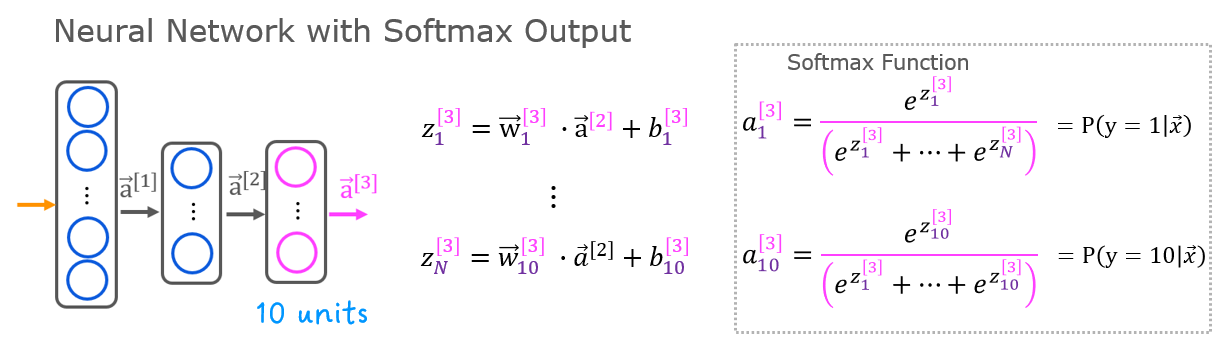

Softmax function:
$$a_j = \frac{e^{z_j}}{ \sum_{k=0}^{N-1}{e^{z_k} }} \tag{1}$$

- Where $z = \mathbf{w} \cdot \mathbf{x} + b$ and N is the number of feature/categories in the output layer.
- Where e = Euler's Number which is aprox `2.71828`

## Exercise 1 - NumPy Implementation

In [18]:
def my_softmax(z):  
    """ Softmax converts a vector of values to a probability distribution.
    Args:
      z (ndarray (N,))  : input data, N features
    Returns:
      a (ndarray (N,))  : softmax of z
    """    
    ### START CODE HERE ###
    
    # Calculate e^z for every element.
    ez = np.e ** z
    
    # Calculate the sum
    sum_ez = np.sum(ez)
    
    # Normalize by dividing every element by the sum
    a = ez / sum_ez
    
    ### END CODE HERE ### 
    return a

In [19]:
z = np.array([1., 2., 3., 4.])
a = my_softmax(z)
atf = tf.nn.softmax(z)
print(f"my_softmax(z):         {a}")
print(f"tensorflow softmax(z): {atf}")

# BEGIN UNIT TEST  
test_my_softmax(my_softmax)
# END UNIT TEST  

my_softmax(z):         [0.03 0.09 0.24 0.64]
tensorflow softmax(z): [0.03 0.09 0.24 0.64]
 All tests passed.


**Comparing Z and softmax(z)**

Notice how the exponential in the numerator maginifes small differences in the values.

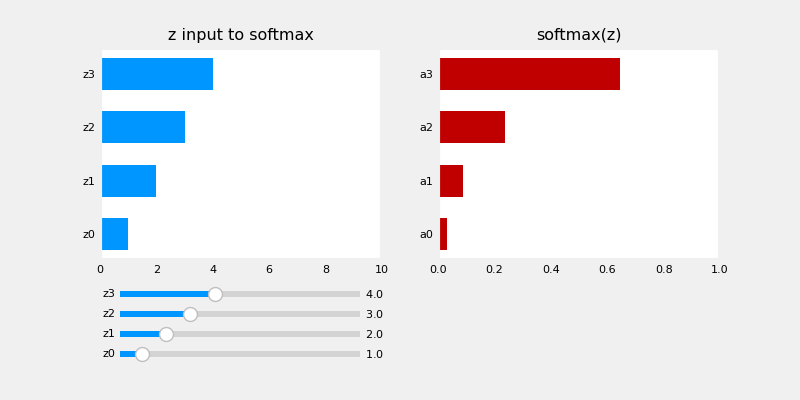

SUM: 1.0


In [20]:
plt.close("all")
plt_softmax(my_softmax)
# Check if the values add up to 1.0
print (f"SUM: {sum(a)}")

## 4 - Neural Networks

Hand writting to digit neural network example.
- The data set includes 5,000 training examples.
- Each example is a 20x20 pixel grayscale image of the digit.
    - Pixels are represented as floating point numbers indicating the grayscale intensity of that pixel.
    - Each 20x20 grid of pixes is "unrolled" into a 400-dimensional vector (single row).

$$X = 
\left(\begin{array}{cc} 
--- (x^{(1)}) --- \\
--- (x^{(2)}) --- \\
\vdots \\ 
--- (x^{(m)}) --- 
\end{array}\right)$$

The second part of the training set is a 5,000 item vector `y` with the answers for each training item in `X`.

In [21]:
# load dataset
X, y = load_data()

In [22]:
# Print example image
print ('The first element of X is: ', X[0])

The first element of X is:  [ 0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  8.56e-06  1.94e-06 -7.37e-04
 -8.13e-03 -1.86e-02 -1.87e-02 -1.88e-02 -1.91e-02 -1.64e-02 -3.78e-03
  3.30e-04  1.28e-05  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  1.16e-04  1.20e-04 -1.40e-02 -2.85e-02  8.04e-02
  2.67e-01  2.74e-01  2.79e-01  2.74e-01  2.25e-0

In [23]:
print ('The first element of y is: ', y[0,0])
print ('The last element of y is: ', y[-1,0])

The first element of y is:  0
The last element of y is:  9


In [24]:
print ('The shape of X is: ' + str(X.shape))
print ('The shape of y is: ' + str(y.shape))

The shape of X is: (5000, 400)
The shape of y is: (5000, 1)


#### 4.1 - Rendering some items

The code block below randomly selects items from the input training data `X`, and renders them as images.

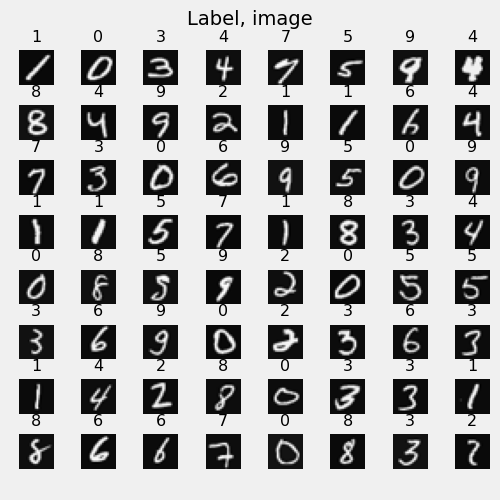

In [25]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# You do not need to modify anything in this cell

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(5,5))
fig.tight_layout(pad=0.13,rect=[0, 0.03, 1, 0.91]) #[left, bottom, right, top]

#fig.tight_layout(pad=0.5)
widgvis(fig)
for i,ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)
    
    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped = X[random_index].reshape((20,20)).T
    
    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')
    
    # Display the label above the image
    ax.set_title(y[random_index,0])
    ax.set_axis_off()
    fig.suptitle("Label, image", fontsize=14)

## 4.3 Model Representation

The model for this assignment is show below. It contains two dense layers with ReLU activations followed by an output layer with linear activation.

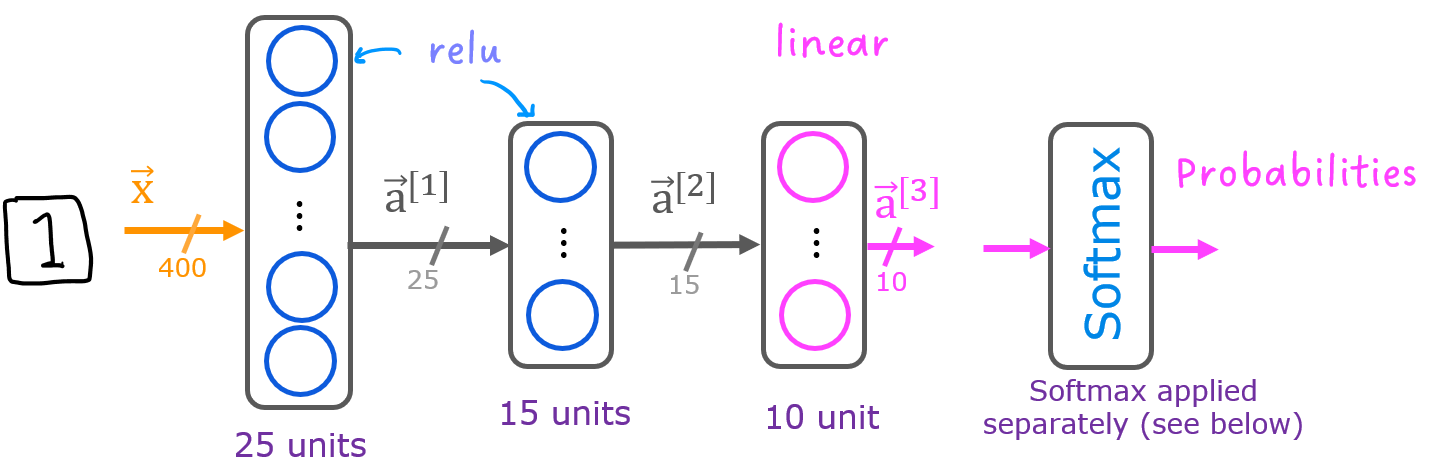

The params have imensions sized for a neural network in the following shape:
- Layer 1: 25 units
- Layer 2: 15 units
- Layer 3: 10 outputs (one for each potential digit)

Reminder, shaping the params:
- If a network has $s_{in}$ units in a layer and $s_{out}$ units in the next layer, then:
    - W will be of dimension $s_{in} X s_{out}$.
    - b will be a vector with $s_{out}$ elements.

- Therefore, the shapes of `W`, and `b`,  are 
    - layer1: The shape of `W1` is (400, 25) and the shape of `b1` is (25,)
    - layer2: The shape of `W2` is (25, 15) and the shape of `b2` is: (15,)
    - layer3: The shape of `W3` is (15, 10) and the shape of `b3` is: (10,)

## 4.4 Tensorflow Model Implementation

- Tensor flow calculates input dimensions automatically.
- We specifiy the layers output dimensions and this in turn determines the input dimension of the next layer.
- The input dimension of the first layer is derived from the size of the input data specified in the `model.fit` statement.
- NOTE: It is possible to add an input layer that specifeid the input dimensions of the first layer. Ex: `tf.kera.Input(shape=(400,)),`

## 4.5 Softmax Placement

- Numerical stability is improved if the softmax is grouped with the loss function ather than the output layer during training. This has implicaitons:
    - The final Dense layer should use `linear` activation (AKA no activation).
    - This will be indicated by `from_logits=True` in `model.compile`.
- The outputs are not probabilities. If probabilites are desired, apply softmax function.

In [26]:
# Using keras sequential model and dense layer with relu activation to construct the three layers descrived above.
tf.random.set_seed(1234)
model = Sequential(
    [               
        tf.keras.Input(shape=(400,)),                # Input
        Dense(25, activation="relu", name="L1"),     # Layer 1
        Dense(15, activation='relu',  name = "L2"),  # Layer 2
        Dense(10, activation='linear', name = "L3"), # Layer 3 
    ], name = "my_model" 
)

model.summary()

Model: "my_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 25)             │        10,025 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2 (Dense)                      │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L3 (Dense)                      │ (None, 10)             │           160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,575 (41.31 KB)

 Trainable params: 10,575 (41.31 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
[layer1, layer2, layer3] = model.layers

#### Examine Weights shapes
W1,b1 = layer1.get_weights()
W2,b2 = layer2.get_weights()
W3,b3 = layer3.get_weights()
print(f"W1 shape = {W1.shape}, b1 shape = {b1.shape}")
print(f"W2 shape = {W2.shape}, b2 shape = {b2.shape}")
print(f"W3 shape = {W3.shape}, b3 shape = {b3.shape}")

W1 shape = (400, 25), b1 shape = (25,)
W2 shape = (25, 15), b2 shape = (15,)
W3 shape = (15, 10), b3 shape = (10,)


In [ ]:
# Defines the loss function, "SparseCategoricalCrossentropy" and idicates that softmax
# should be included with the loss calculation by adding "from_logits=true"
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
)

history = model.fit(
    X,y,
    epochs=40  # The entire data will be applied 40 times during training.
)

Epoch 1/40


I0000 00:00:1768334896.880835  101946 service.cc:146] XLA service 0x75a814015ca0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768334896.880851  101946 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-01-13 15:08:16.898021: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-13 15:08:16.969465: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


120/157 ━━━━━━━━━━━━━━━━━━━━ 0s 446us/step - loss: 1.9922

I0000 00:00:1768334897.467680  101946 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.8899 
Epoch 2/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 392us/step - loss: 0.7162
Epoch 3/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 411us/step - loss: 0.4530
Epoch 4/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 407us/step - loss: 0.3621
Epoch 5/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 393us/step - loss: 0.3081
Epoch 6/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 368us/step - loss: 0.2714
Epoch 7/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 417us/step - loss: 0.2436
Epoch 8/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 437us/step - loss: 0.2230
Epoch 9/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 392us/step - loss: 0.2064
Epoch 10/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 404us/step - loss: 0.1922
Epoch 11/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 401us/step - loss: 0.1803
Epoch 12/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 395us/step - loss: 0.1698
Epoch 13/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 386us/step - loss: 0.1606
Epoch 14/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 359us/step - loss: 0.1521
Epoch 15/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 

## Making a prediction

Using Keras predict with an image of a 2.

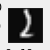

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
 predicting a Two: 
[[ -7.31   0.7    4.6   -1.27  -8.27  -4.64  -3.26   1.17  -6.95 -10.73]]
 Largest Prediction index: 2


In [32]:
image_of_two = X[1015]
display_digit(image_of_two)

prediction = model.predict(image_of_two.reshape(1,400))  # prediction

print(f" predicting a Two: \n{prediction}")
print(f" Largest Prediction index: {np.argmax(prediction)}")

The largest output is `4.6`, which is the prediction of a 2.

In [33]:
# Numpy argmax can bu utilized to select the prediction
prediction_p = tf.nn.softmax(prediction)

print(f" predicting a Two. Probability vector: \n{prediction_p}")
print(f"Total of predictions: {np.sum(prediction_p):0.3f}")

 predicting a Two. Probability vector: 
[[6.37e-06 1.92e-02 9.47e-01 2.69e-03 2.45e-06 9.24e-05 3.65e-04 3.07e-02
  9.18e-06 2.09e-07]]
Total of predictions: 1.000


In [34]:
# The Numpy armax func can be used as an index to obtain the largest probabilit.
yhat = np.argmax(prediction_p)

print(f"np.argmax(prediction_p): {yhat}")

np.argmax(prediction_p): 2


Rendering predictions alongside their inputs

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━

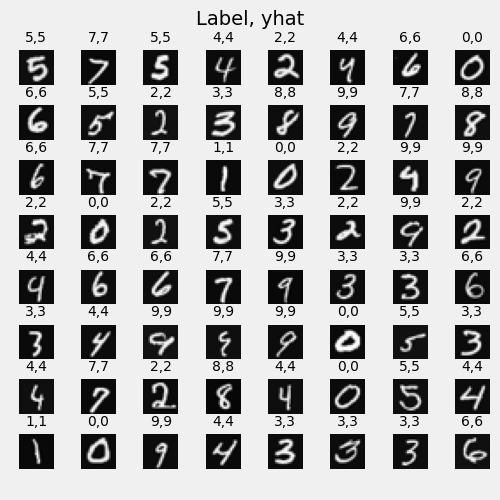

In [35]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# You do not need to modify anything in this cell

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(5,5))
fig.tight_layout(pad=0.13,rect=[0, 0.03, 1, 0.91]) #[left, bottom, right, top]
widgvis(fig)
for i,ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)
    
    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped = X[random_index].reshape((20,20)).T
    
    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')
    
    # Predict using the Neural Network
    prediction = model.predict(X[random_index].reshape(1,400))
    prediction_p = tf.nn.softmax(prediction)
    yhat = np.argmax(prediction_p)
    
    # Display the label above the image
    ax.set_title(f"{y[random_index,0]},{yhat}",fontsize=10)
    ax.set_axis_off()
fig.suptitle("Label, yhat", fontsize=14)
plt.show()

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 882us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
30 errors out of 5000 images


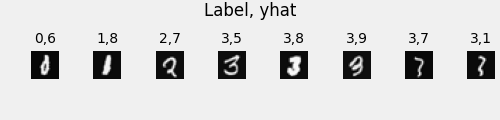

In [36]:
# Render some errors

print( f"{display_errors(model,X,y)} errors out of {len(X)} images")